 Task 1 — Sales & Demand Forecasting for Businesses


 Step 1: Import Libraries



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Make our charts look nice
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


 Step 2: Create / Load Sales Data



In [9]:
# Set a random seed so our "random" data is reproducible
# (same results every time you run this)
np.random.seed(42)

# Create a date range: Jan 2022 to Dec 2024 (3 years of daily data)
dates = pd.date_range(start='2022-01-01', end='2024-12-31', freq='D')
n = len(dates)  # total number of days

print(f'📅 Total days of data: {n}')
print(f'📅 From: {dates[0].date()} → To: {dates[-1].date()}')

# --- Build each component of sales ---

# 1. TREND: Sales grow ~50% over 3 years
# linspace gives evenly spaced numbers from 0 to 1
trend = np.linspace(0, 500, n)

# 2. SEASONALITY: Sales peak in December, low in Feb
# We use a sine wave that repeats every year (365 days)
# Amplitude = 300 means sales swing ±300 units seasonally
day_of_year = np.arange(n) % 365
seasonality = 300 * np.sin(2 * np.pi * (day_of_year - 90) / 365)

# 3. WEEKLY PATTERN: Weekends get +100 sales
day_of_week = pd.Series(dates).dt.dayofweek.values  # 0=Mon, 6=Sun
weekly = np.where(day_of_week >= 5, 100, 0)  # 5=Sat, 6=Sun

# 4. RANDOM NOISE: ±150 units of random daily variation
noise = np.random.normal(0, 150, n)

# 5. BASE SALES: The minimum sales on any normal day
base = 1000

# COMBINE all components
sales = base + trend + seasonality + weekly + noise

# Make sure no negative sales (clip at 0)
sales = np.clip(sales, 0, None)

# Create a clean DataFrame (table)
df = pd.DataFrame({
    'Date': dates,
    'Sales': sales.round(2)
})

print('\n📊 First 5 rows of our dataset:')
print(df.head())
print(f'\n📊 Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')

📅 Total days of data: 1096
📅 From: 2022-01-01 → To: 2024-12-31

📊 First 5 rows of our dataset:
        Date   Sales
0 2022-01-01  874.58
1 2022-01-02  779.94
2 2022-01-03  798.54
3 2022-01-04  930.63
4 2022-01-05  667.93

📊 Dataset shape: 1096 rows × 2 columns


 Step 3: Data Cleaning & Time-Based Feature Engineering



In [12]:
# Set Date as the index (time series standard practice)
df.set_index('Date', inplace=True)

# Check for missing values
print('🔍 Missing values check:')
print(df.isnull().sum())

# --- FEATURE ENGINEERING ---
# Extract time-based features from the date index

df['Year'] = df.index.year                    # 2022, 2023, 2024
df['Month'] = df.index.month                  # 1-12
df['Day'] = df.index.day                      # 1-31
df['DayOfWeek'] = df.index.dayofweek          # 0=Mon to 6=Sun
df['DayOfYear'] = df.index.dayofyear          # 1-365
df['Quarter'] = df.index.quarter              # 1-4
df['IsWeekend'] = (df.index.dayofweek >= 5).astype(int)  # 1=weekend, 0=weekday
df['WeekOfYear'] = df.index.isocalendar().week.astype(int)  # 1-52

# LAG FEATURES: Past sales values
# "What were sales 7 days ago?" → very predictive!
df['Lag_7'] = df['Sales'].shift(7)    # 7 days ago
df['Lag_14'] = df['Sales'].shift(14)  # 14 days ago
df['Lag_30'] = df['Sales'].shift(30)  # 30 days ago

# ROLLING AVERAGES: Smooth trends
# Average of last 7 days (removes noise, shows trend)
df['Rolling_7'] = df['Sales'].rolling(window=7).mean()
df['Rolling_30'] = df['Sales'].rolling(window=30).mean()

# Drop rows with NaN (caused by lag/rolling features at the start)
df.dropna(inplace=True)

print('\n✅ Feature engineering complete!')
print(f'📊 Dataset after cleaning: {df.shape[0]} rows × {df.shape[1]} columns')
print('\n📋 Columns created:')
for col in df.columns:
    print(f'  → {col}')

🔍 Missing values check:
Sales    0
dtype: int64

✅ Feature engineering complete!
📊 Dataset after cleaning: 1066 rows × 14 columns

📋 Columns created:
  → Sales
  → Year
  → Month
  → Day
  → DayOfWeek
  → DayOfYear
  → Quarter
  → IsWeekend
  → WeekOfYear
  → Lag_7
  → Lag_14
  → Lag_30
  → Rolling_7
  → Rolling_30


 Step 4: Exploratory Data Analysis (EDA)



📊 Basic Statistics of Sales:
count    1066.00
mean     1298.99
std       293.58
min       485.66
25%      1078.53
50%      1296.36
75%      1505.90
max      2090.12
Name: Sales, dtype: float64


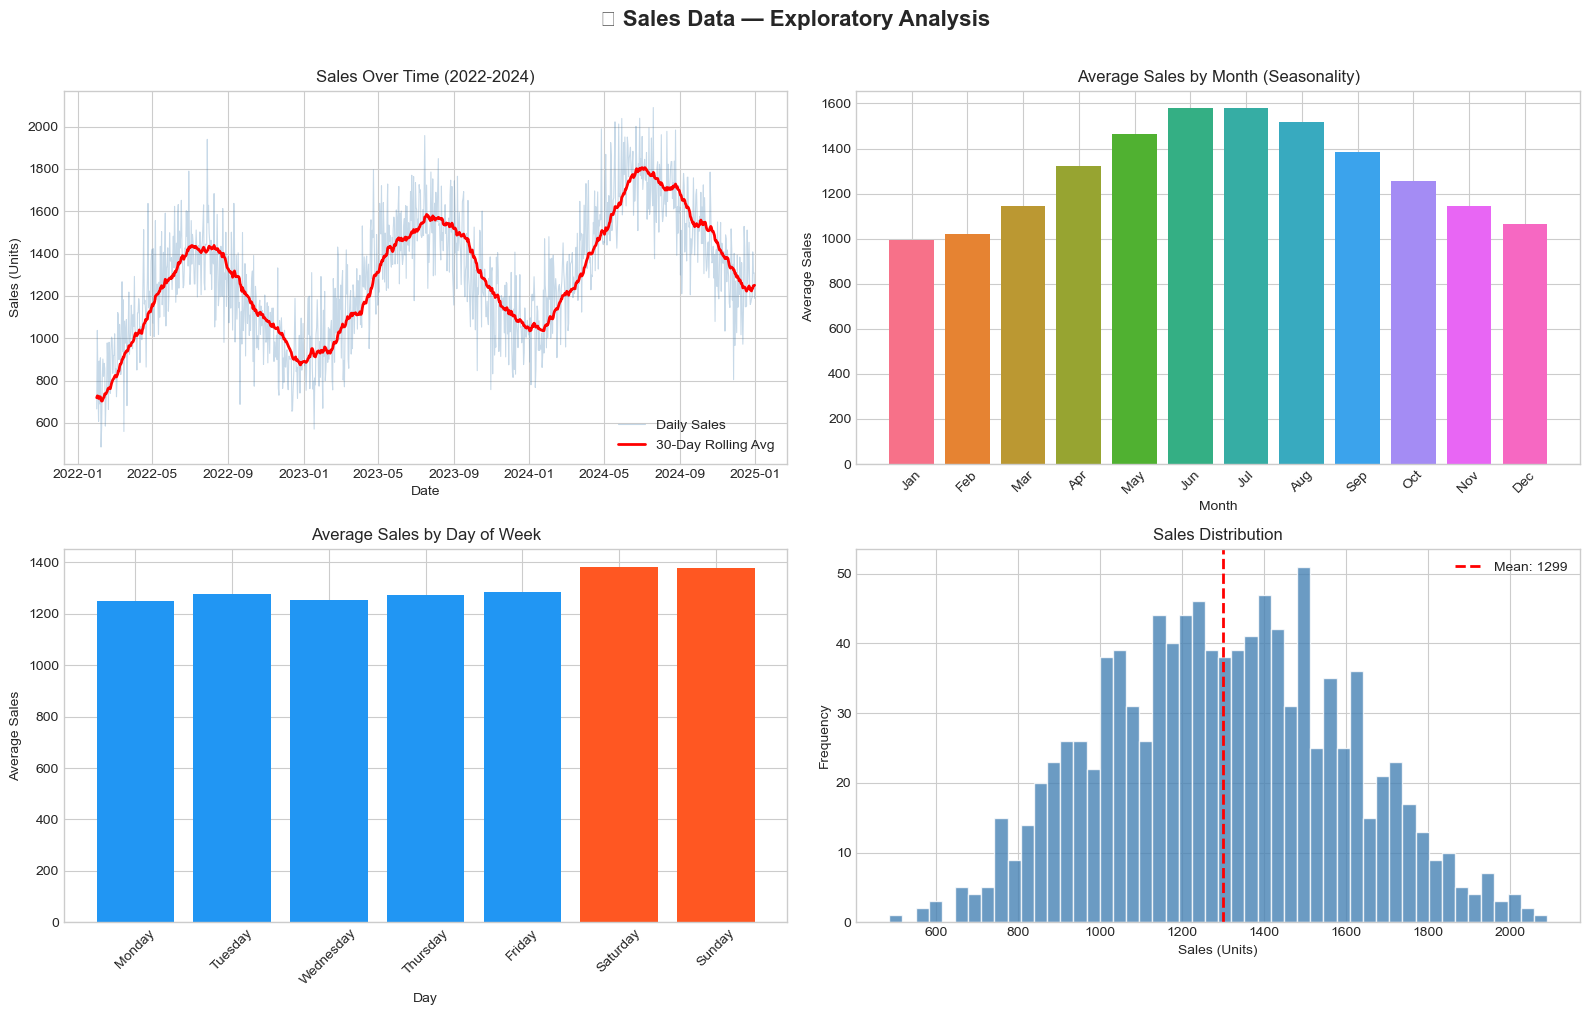


📊 Key Insights from EDA:
  • Average daily sales: 1299 units
  • Best month: Jun (1578 avg units)
  • Worst month: Jan (996 avg units)
  • Best day: Saturday (1383 avg units)


In [15]:
print('📊 Basic Statistics of Sales:')
print(df['Sales'].describe().round(2))

# Monthly average sales
monthly_avg = df.groupby('Month')['Sales'].mean().round(2)
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# Day-of-week average
dow_avg = df.groupby('DayOfWeek')['Sales'].mean().round(2)
day_names = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# --- PLOT 1: Overall Sales Trend ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('📊 Sales Data — Exploratory Analysis', fontsize=16, fontweight='bold', y=1.01)

# Plot 1: Full sales timeline with 30-day rolling average
axes[0, 0].plot(df.index, df['Sales'], alpha=0.3, color='steelblue', linewidth=0.8, label='Daily Sales')
axes[0, 0].plot(df.index, df['Rolling_30'], color='red', linewidth=2, label='30-Day Rolling Avg')
axes[0, 0].set_title('Sales Over Time (2022-2024)')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Sales (Units)')
axes[0, 0].legend()

# Plot 2: Average sales by month (seasonality)
axes[0, 1].bar(month_names, monthly_avg.values, color=sns.color_palette('husl', 12))
axes[0, 1].set_title('Average Sales by Month (Seasonality)')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Average Sales')
axes[0, 1].tick_params(axis='x', rotation=45)

# Plot 3: Average sales by day of week
axes[1, 0].bar(day_names, dow_avg.values, color=['#2196F3']*5 + ['#FF5722']*2)
axes[1, 0].set_title('Average Sales by Day of Week')
axes[1, 0].set_xlabel('Day')
axes[1, 0].set_ylabel('Average Sales')
axes[1, 0].tick_params(axis='x', rotation=45)

# Plot 4: Sales distribution (histogram)
axes[1, 1].hist(df['Sales'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[1, 1].axvline(df['Sales'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df['Sales'].mean():.0f}")
axes[1, 1].set_title('Sales Distribution')
axes[1, 1].set_xlabel('Sales (Units)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📊 Key Insights from EDA:')
print(f'  • Average daily sales: {df["Sales"].mean():.0f} units')
print(f'  • Best month: {month_names[monthly_avg.idxmax()-1]} ({monthly_avg.max():.0f} avg units)')
print(f'  • Worst month: {month_names[monthly_avg.idxmin()-1]} ({monthly_avg.min():.0f} avg units)')
print(f'  • Best day: {day_names[dow_avg.idxmax()]} ({dow_avg.max():.0f} avg units)')

# Step 5: Build & Train the ML Model


In [24]:
# Define FEATURES (X) and TARGET (y)
# Features = what we give the model as input
# Target = what we want it to predict

feature_columns = ['Year', 'Month', 'Day', 'DayOfWeek', 'DayOfYear',
                   'Quarter', 'IsWeekend', 'WeekOfYear',
                   'Lag_7', 'Lag_14', 'Lag_30',
                   'Rolling_7', 'Rolling_30']

X = df[feature_columns]  # Input features
y = df['Sales']          # Target variable

# Split into training and testing sets
# shuffle=False is CRITICAL for time-series! We must keep time order.
# (Never train on future data to predict the past)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(f'🏋️ Training samples: {len(X_train)} days')
print(f'🧪 Testing samples:  {len(X_test)} days')

# --- MODEL 1: Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)  # Train the model
lr_predictions = lr_model.predict(X_test)  # Make predictions

# --- MODEL 2: Random Forest ---
# n_estimators=100 means 100 decision trees
# random_state=42 for reproducibility
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

print('\n✅ Both models trained successfully!')

🏋️ Training samples: 852 days
🧪 Testing samples:  214 days

✅ Both models trained successfully!


##  Step 6: Model Evaluation



In [26]:
def evaluate_model(name, y_true, y_pred):
    """Calculate and print evaluation metrics for a model."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100  # % error
    
    print(f'\n📊 {name} Performance:')
    print(f'  MAE  (Mean Absolute Error):     {mae:.2f} units')
    print(f'  RMSE (Root Mean Squared Error): {rmse:.2f} units')
    print(f'  R²   (R-squared Score):         {r2:.4f}  ({r2*100:.1f}% accuracy)')
    print(f'  MAPE (Mean Abs % Error):        {mape:.2f}%')
    
    return {'name': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

results_lr = evaluate_model('Linear Regression', y_test, lr_predictions)
results_rf = evaluate_model('Random Forest', y_test, rf_predictions)

print('\n🏆 Winner:', 'Random Forest' if results_rf['R2'] > results_lr['R2'] else 'Linear Regression')


📊 Linear Regression Performance:
  MAE  (Mean Absolute Error):     103.08 units
  RMSE (Root Mean Squared Error): 129.69 units
  R²   (R-squared Score):         0.7265  (72.6% accuracy)
  MAPE (Mean Abs % Error):        7.00%

📊 Random Forest Performance:
  MAE  (Mean Absolute Error):     112.63 units
  RMSE (Root Mean Squared Error): 141.03 units
  R²   (R-squared Score):         0.6766  (67.7% accuracy)
  MAPE (Mean Abs % Error):        7.61%

🏆 Winner: Linear Regression


##  Step 7: Forecast Future Sales (Next 90 Days)



In [28]:
# Create future dates: next 90 days after our data ends
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=90, freq='D')

# Build a DataFrame for future dates
future_df = pd.DataFrame(index=future_dates)
future_df['Year'] = future_df.index.year
future_df['Month'] = future_df.index.month
future_df['Day'] = future_df.index.day
future_df['DayOfWeek'] = future_df.index.dayofweek
future_df['DayOfYear'] = future_df.index.dayofyear
future_df['Quarter'] = future_df.index.quarter
future_df['IsWeekend'] = (future_df.index.dayofweek >= 5).astype(int)
future_df['WeekOfYear'] = future_df.index.isocalendar().week.astype(int)

# For lag and rolling features in future, use last known values
last_7  = df['Sales'].tail(7).mean()
last_14 = df['Sales'].tail(14).mean()
last_30 = df['Sales'].tail(30).mean()

future_df['Lag_7']    = last_7
future_df['Lag_14']   = last_14
future_df['Lag_30']   = last_30
future_df['Rolling_7']  = last_7
future_df['Rolling_30'] = last_30

# Predict using Random Forest (our best model)
future_predictions = rf_model.predict(future_df[feature_columns])
future_df['Predicted_Sales'] = future_predictions.round(0)

print('🔮 Next 90-Day Sales Forecast (First 10 days):')
print(future_df['Predicted_Sales'].head(10).to_string())
print(f'\n📊 Forecast Summary:')
print(f'  Total predicted sales (90 days): {future_df["Predicted_Sales"].sum():,.0f} units')
print(f'  Average daily sales:             {future_df["Predicted_Sales"].mean():,.0f} units')
print(f'  Peak day forecast:               {future_df["Predicted_Sales"].max():,.0f} units')

🔮 Next 90-Day Sales Forecast (First 10 days):
2025-01-01    1285.0
2025-01-02    1292.0
2025-01-03    1303.0
2025-01-04    1340.0
2025-01-05    1358.0
2025-01-06    1262.0
2025-01-07    1265.0
2025-01-08    1297.0
2025-01-09    1301.0
2025-01-10    1304.0
Freq: D

📊 Forecast Summary:
  Total predicted sales (90 days): 117,264 units
  Average daily sales:             1,303 units
  Peak day forecast:               1,382 units


##  Step 8: Business-Friendly Visualization



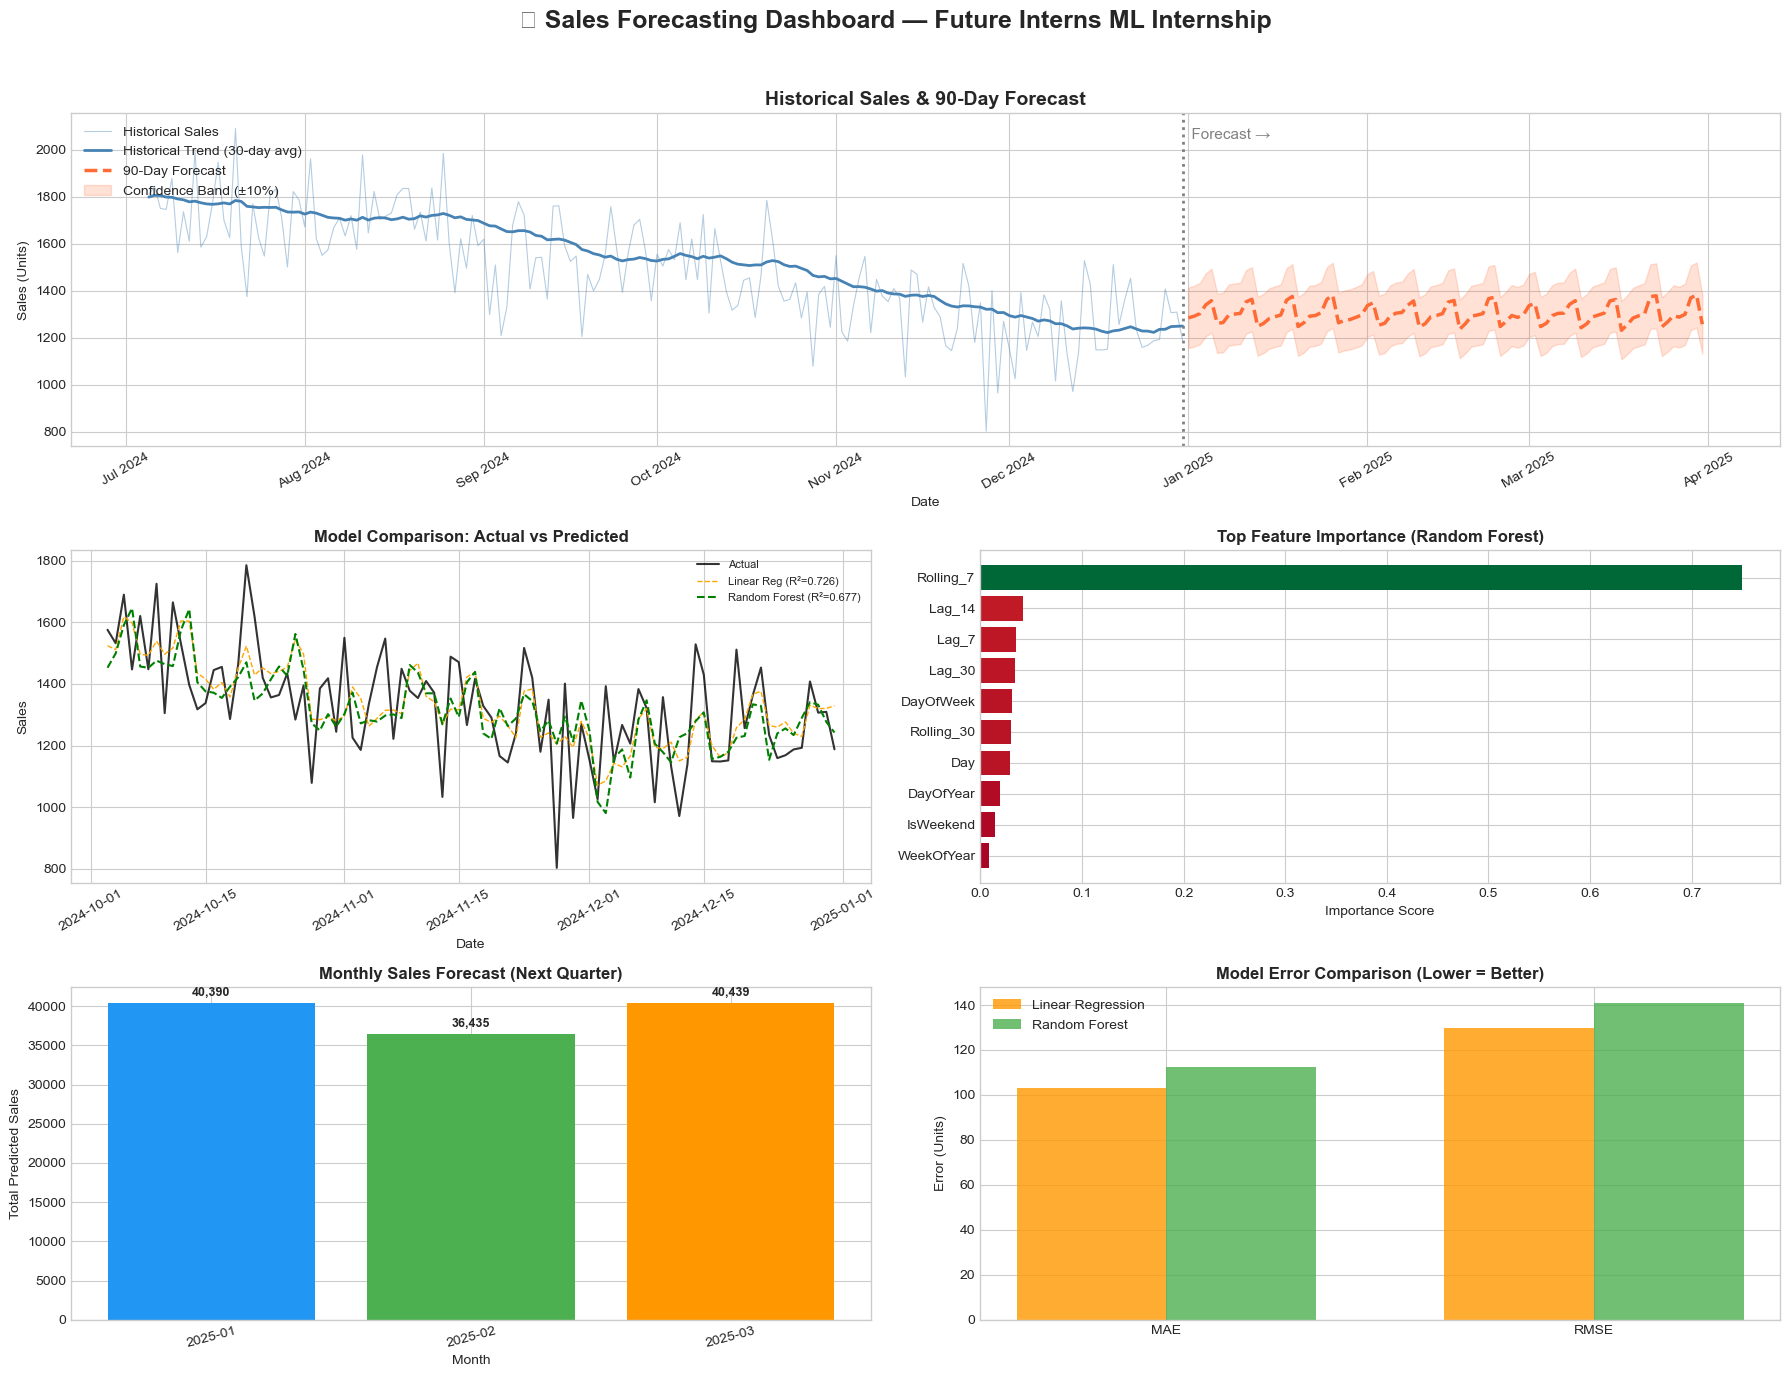

✅ Dashboard saved as sales_forecast_dashboard.png


In [31]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle('📊 Sales Forecasting Dashboard — Future Interns ML Internship',
             fontsize=18, fontweight='bold', y=0.98)

# ---- Plot 1: Main Forecast Chart ----
ax1 = fig.add_subplot(3, 2, (1, 2))  # spans top two columns

# Show last 6 months of historical data
historical_window = df['Sales'].tail(180)
historical_rolling = df['Rolling_30'].tail(180)

ax1.plot(historical_window.index, historical_window.values,
         alpha=0.4, color='steelblue', linewidth=0.8, label='Historical Sales')
ax1.plot(historical_rolling.index, historical_rolling.values,
         color='steelblue', linewidth=2, label='Historical Trend (30-day avg)')

# Forecast line
ax1.plot(future_df.index, future_df['Predicted_Sales'],
         color='#FF6B35', linewidth=2.5, linestyle='--', label='90-Day Forecast')

# Confidence band (±10% uncertainty zone)
ax1.fill_between(future_df.index,
                 future_df['Predicted_Sales'] * 0.90,
                 future_df['Predicted_Sales'] * 1.10,
                 alpha=0.2, color='#FF6B35', label='Confidence Band (±10%)')

# Vertical line showing where history ends and forecast begins
ax1.axvline(x=last_date, color='gray', linestyle=':', linewidth=2)
ax1.text(last_date, ax1.get_ylim()[1] * 0.95, '  Forecast →',
         fontsize=11, color='gray')

ax1.set_title('Historical Sales & 90-Day Forecast', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Sales (Units)')
ax1.legend(loc='upper left', fontsize=10)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.tick_params(axis='x', rotation=30)

# ---- Plot 2: Model Comparison ----
ax2 = fig.add_subplot(3, 2, 3)
last_90_actual = y_test.tail(90)
last_90_lr = lr_predictions[-90:]
last_90_rf = rf_predictions[-90:]

ax2.plot(last_90_actual.index, last_90_actual.values,
         color='black', linewidth=1.5, label='Actual', alpha=0.8)
ax2.plot(last_90_actual.index, last_90_lr,
         color='orange', linewidth=1, linestyle='--', label=f'Linear Reg (R²={results_lr["R2"]:.3f})')
ax2.plot(last_90_actual.index, last_90_rf,
         color='green', linewidth=1.5, linestyle='--', label=f'Random Forest (R²={results_rf["R2"]:.3f})')
ax2.set_title('Model Comparison: Actual vs Predicted', fontsize=12, fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Sales')
ax2.legend(fontsize=8)
ax2.tick_params(axis='x', rotation=30)

# ---- Plot 3: Feature Importance ----
ax3 = fig.add_subplot(3, 2, 4)
feat_importance = pd.Series(rf_model.feature_importances_, index=feature_columns)
feat_importance = feat_importance.sort_values(ascending=True).tail(10)
bars = ax3.barh(feat_importance.index, feat_importance.values,
                color=plt.cm.RdYlGn(feat_importance.values / feat_importance.max()))
ax3.set_title('Top Feature Importance (Random Forest)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Importance Score')

# ---- Plot 4: Monthly Forecast Bar Chart ----
ax4 = fig.add_subplot(3, 2, 5)
monthly_forecast = future_df.groupby(future_df.index.to_period('M'))['Predicted_Sales'].sum()
months_str = [str(m) for m in monthly_forecast.index]
bars4 = ax4.bar(months_str, monthly_forecast.values,
                color=['#2196F3', '#4CAF50', '#FF9800'][:len(monthly_forecast)])
for bar, val in zip(bars4, monthly_forecast.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax4.set_title('Monthly Sales Forecast (Next Quarter)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Month')
ax4.set_ylabel('Total Predicted Sales')
ax4.tick_params(axis='x', rotation=15)

# ---- Plot 5: Model Metrics Comparison ----
ax5 = fig.add_subplot(3, 2, 6)
metrics = ['MAE', 'RMSE']
lr_vals = [results_lr['MAE'], results_lr['RMSE']]
rf_vals = [results_rf['MAE'], results_rf['RMSE']]
x = np.arange(len(metrics))
width = 0.35
ax5.bar(x - width/2, lr_vals, width, label='Linear Regression', color='#FF9800', alpha=0.8)
ax5.bar(x + width/2, rf_vals, width, label='Random Forest', color='#4CAF50', alpha=0.8)
ax5.set_title('Model Error Comparison (Lower = Better)', fontsize=12, fontweight='bold')
ax5.set_xticks(x)
ax5.set_xticklabels(metrics)
ax5.set_ylabel('Error (Units)')
ax5.legend()

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('sales_forecast_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Dashboard saved as sales_forecast_dashboard.png')

##  Step 9: Business Insights Report



In [34]:
print('=' * 60)
print('       📋 BUSINESS INSIGHTS REPORT')
print('       Sales & Demand Forecasting Analysis')
print('=' * 60)

print('\n🏆 MODEL PERFORMANCE')
print(f'  Best Model: Random Forest Regressor')
print(f'  Accuracy (R² Score): {results_rf["R2"]*100:.1f}%')
print(f'  Average Error: ±{results_rf["MAE"]:.0f} units per day')
print(f'  Error Rate (MAPE): {results_rf["MAPE"]:.1f}%')

print('\n📅 HISTORICAL PERFORMANCE (2022-2024)')
yearly = df.groupby('Year')['Sales'].agg(['sum', 'mean']).round(0)
for year, row in yearly.iterrows():
    print(f'  {year}: Total = {row["sum"]:,.0f} units | Daily Avg = {row["mean"]:,.0f} units')

print('\n🔮 90-DAY SALES FORECAST')
monthly_forecast = future_df.groupby(future_df.index.to_period('M'))['Predicted_Sales'].agg(['sum','mean'])
for period, row in monthly_forecast.iterrows():
    print(f'  {period}: ~{row["sum"]:,.0f} total units (avg {row["mean"]:,.0f}/day)')

best_month = monthly_avg.idxmax()
worst_month = monthly_avg.idxmin()

print('\n🎯 ACTIONABLE BUSINESS RECOMMENDATIONS')
print(f'  1. 📦 STOCK UP in {month_names[best_month-1]} — historically highest demand month')
print(f'     → Ensure inventory is {monthly_avg.max()/monthly_avg.mean()*100:.0f}% above average')
print(f'  2. 💰 RUN PROMOTIONS in {month_names[worst_month-1]} — lowest sales period')
print(f'     → Can increase revenue by targeting slow periods')
print(f'  3. 🛒 STAFF UP on Weekends — {dow_avg.max()/dow_avg.mean()*100:.0f}% above average sales')
print(f'  4. 📈 SALES TREND is UPWARD — business growing ~{(df[df["Year"]==2024]["Sales"].mean() / df[df["Year"]==2022]["Sales"].mean() - 1)*100:.0f}% vs 2022')
print(f'  5. 🎯 MODEL ERROR is ±{results_rf["MAE"]:.0f} units — use this as inventory buffer')

print('\n🔑 TOP PREDICTIVE FEATURES (What drives sales most?)')
top_features = pd.Series(rf_model.feature_importances_, index=feature_columns).nlargest(5)
for feat, importance in top_features.items():
    print(f'  {feat}: {importance:.3f} ({importance*100:.1f}% contribution)')

print('\n' + '=' * 60)
print('✅ Analysis Complete | GitHub: FUTURE_ML_01')
print('=' * 60)

       📋 BUSINESS INSIGHTS REPORT
       Sales & Demand Forecasting Analysis

🏆 MODEL PERFORMANCE
  Best Model: Random Forest Regressor
  Accuracy (R² Score): 67.7%
  Average Error: ±113 units per day
  Error Rate (MAPE): 7.6%

📅 HISTORICAL PERFORMANCE (2022-2024)
  2022: Total = 384,601 units | Daily Avg = 1,148 units
  2023: Total = 464,585 units | Daily Avg = 1,273 units
  2024: Total = 535,538 units | Daily Avg = 1,463 units

🔮 90-DAY SALES FORECAST
  2025-01: ~40,390 total units (avg 1,303/day)
  2025-02: ~36,435 total units (avg 1,301/day)
  2025-03: ~40,439 total units (avg 1,304/day)

🎯 ACTIONABLE BUSINESS RECOMMENDATIONS
  1. 📦 STOCK UP in Jun — historically highest demand month
     → Ensure inventory is 122% above average
  2. 💰 RUN PROMOTIONS in Jan — lowest sales period
     → Can increase revenue by targeting slow periods
  3. 🛒 STAFF UP on Weekends — 106% above average sales
  4. 📈 SALES TREND is UPWARD — business growing ~27% vs 2022
  5. 🎯 MODEL ERROR is ±113 units — u